In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from math import ceil
from itertools import zip_longest

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV, cross_val_score
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import KFold, RandomizedSearchCV, cross_val_score

In [2]:
df = pd.read_csv('Airbnb_Data.csv')
df

,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,...,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds
0,6901257,5.010635,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",3,1.0,Real Bed,strict,True,...,40.696524,-73.991617,Beautiful brownstone 1-bedroom,Brooklyn Heights,2,100.0,https://a0.muscache.com/im/pictures/6d7cbbf7-c...,11201,1.0,1.0
1,6304928,5.129899,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",7,1.0,Real Bed,strict,True,...,40.766115,-73.989040,Superb 3BR Apt Located Near Times Square,Hell's Kitchen,6,93.0,https://a0.muscache.com/im/pictures/348a55fe-4...,10019,3.0,3.0
2,7919400,4.976734,Apartment,Entire home/apt,"{TV,""Cable TV"",""Wireless Internet"",""Air condit...",5,1.0,Real Bed,moderate,True,...,40.808110,-73.943756,The Garden Oasis,Harlem,10,92.0,https://a0.muscache.com/im/pictures/6fae5362-9...,10027,1.0,3.0
3,13418779,6.620073,House,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4,1.0,Real Bed,flexible,True,...,37.772004,-122.431619,Beautiful Flat in the Heart of SF!,Lower Haight,0,NaN,https://a0.muscache.com/im/pictures/72208dad-9...,94117.0,2.0,2.0
4,3808709,4.744932,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",2,1.0,Real Bed,moderate,True,...,38.925627,-77.034596,Great studio in midtown DC,Columbia Heights,4,40.0,NaN,20009,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74106,14549287,4.605170,Apartment,Private room,{},1,1.0,Real Bed,flexible,False,...,40.709025,-73.939405,one room bushwick,Williamsburg,0,NaN,https://a0.muscache.com/im/pictures/55162426/6...,11206.0,1.0,1.0
74107,13281809,5.043425,Apartment,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4,2.0,Real Bed,moderate,True,...,33.871549,-118.396053,Spacious Hermosa 2 BR on PCH,Hermosa Beach,16,93.0,https://a0.muscache.com/im/pictures/2b86560b-a...,90254,2.0,4.0
74108,18688039,5.220356,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",5,1.0,Real Bed,moderate,True,...,40.706749,-73.942377,Modern 2 Bedroom Apartment in Williamsburg,Williamsburg,43,94.0,https://a0.muscache.com/im/pictures/7fbe448c-5...,11206.0,2.0,2.0
74109,17045948,5.273000,Apartment,Entire home/apt,"{TV,""Wireless Internet"",""Air conditioning"",Kit...",2,1.0,Real Bed,strict,True,...,40.738535,-74.000157,Designer's Apartment in HEART of NYC,West Village,0,NaN,https://a0.muscache.com/im/pictures/b3971b63-0...,10011,0.0,2.0


In [3]:
X = df.drop('log_price', axis=1)
y = df['log_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
X_train

,id,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,city,...,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds
12048,760827,House,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",""A...",4,1.5,Real Bed,flexible,False,LA,...,34.109039,-118.273390,Comfortable guesthouse in Los Feliz,Los Feliz,12,97.0,https://a0.muscache.com/im/pictures/68126735/8...,90027,2.0,3.0
48255,3257345,Apartment,Entire home/apt,"{TV,""Wireless Internet"",Kitchen,""Free parking ...",2,1.0,Real Bed,strict,True,NYC,...,40.812897,-73.919163,Garden apartment w/ parking! Colorful Cheery S...,Mott Haven,6,87.0,https://a0.muscache.com/im/pictures/de651e45-a...,10454,1.0,1.0
39959,13355012,Apartment,Entire home/apt,"{TV,""Air conditioning"",Kitchen,Heating,""Smoke ...",4,1.0,Real Bed,strict,True,NYC,...,40.737643,-73.953309,Greenpoint Studio w/ KING bed and Sofabed!,Greenpoint,4,80.0,https://a0.muscache.com/im/pictures/02fe96c0-8...,11222,0.0,2.0
14926,4565981,Apartment,Private room,{},2,1.0,Real Bed,flexible,True,SF,...,37.759935,-122.420558,Comfy Valenica Street bedroom,Mission District,0,NaN,https://a0.muscache.com/im/pictures/03292fda-2...,94110,1.0,1.0
776,6940108,Apartment,Entire home/apt,"{Internet,""Wireless Internet"",""Air conditionin...",3,1.0,Real Bed,moderate,True,NYC,...,40.683363,-73.949490,charming brooklyn apartment,Bedford-Stuyvesant,16,99.0,NaN,11216,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37194,15101498,Apartment,Private room,"{TV,""Wireless Internet"",""Air conditioning"",Kit...",2,1.5,Real Bed,strict,True,LA,...,34.094867,-118.292013,"✿ܓBEAUTFL PRIV #4+PRIVATE 1/2 BA, SHARED FULL ...",East Hollywood,1,100.0,https://a0.muscache.com/im/pictures/7d28c5b1-8...,90029,1.0,1.0
6265,298258,House,Private room,"{TV,Internet,""Wireless Internet"",""Air conditio...",1,1.0,Real Bed,flexible,True,LA,...,34.150509,-118.787469,Lovely room with a view,NaN,2,90.0,https://a0.muscache.com/im/pictures/72186809/2...,91301,1.0,1.0
54886,4917508,House,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",""A...",5,2.0,Real Bed,strict,True,LA,...,34.087073,-118.336914,Amazing 2 bed & 2 bath Melrose dist,Hollywood,20,91.0,https://a0.muscache.com/im/pictures/22515d38-5...,90038,2.0,2.0
860,16645828,Apartment,Private room,"{TV,Internet,""Wireless Internet"",""Air conditio...",2,1.0,Real Bed,strict,True,NYC,...,40.771579,-73.957856,Prime location private room in furnished ap 3b...,Upper East Side,0,NaN,NaN,10021,1.0,1.0


In [5]:
X_test

,id,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,city,...,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds
4079,13662370,House,Private room,"{TV,Internet,""Wireless Internet"",""Air conditio...",2,1.5,Real Bed,strict,True,Chicago,...,41.849684,-87.676270,Pilsen Arts Community Custom Home,Pilsen,17,97.0,https://a0.muscache.com/im/pictures/81318153/a...,60608,1.0,1.0
33735,4765892,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",2,2.0,Real Bed,strict,True,LA,...,34.068613,-118.246455,Apartment 5 minutes from DTLA & Dodger Stadium,Echo Park,2,100.0,https://a0.muscache.com/im/pictures/aa00250e-0...,90012,1.0,1.0
69475,21169968,Apartment,Entire home/apt,"{TV,""Cable TV"",""Wireless Internet"",""Air condit...",5,1.0,Real Bed,moderate,True,NYC,...,40.701958,-73.917352,"Brand New Huge 2bdr apartment(L,M train 2 min)",Bushwick,25,88.0,https://a0.muscache.com/im/pictures/d9220535-c...,11237,2.0,3.0
454,7939196,Apartment,Entire home/apt,"{""Cable TV"",Internet,""Wireless Internet"",""Air ...",6,1.0,Real Bed,strict,True,NYC,...,40.742959,-73.990820,Grande Super Large APT !!!,Flatiron District,12,82.0,NaN,10010,1.0,3.0
25153,18161036,House,Private room,"{Internet,""Wireless Internet"",""Air conditionin...",2,1.0,Real Bed,flexible,True,LA,...,34.046473,-117.734095,Private Cozy and Clean Rooms in Pomona,NaN,2,100.0,https://a0.muscache.com/im/pictures/e0c9b2f9-a...,91766,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4775,9759707,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",4,1.0,Real Bed,strict,True,NYC,...,40.764226,-73.976932,Cozy & Quiet 1 Bedroom - 1 block from central ...,Midtown,5,100.0,https://a0.muscache.com/im/pictures/29cbf250-7...,10019,1.0,2.0
14723,17703848,House,Private room,"{TV,Internet,""Wireless Internet"",""Air conditio...",4,1.0,Real Bed,moderate,True,LA,...,34.134544,-118.360631,King & 2 Twin beds- Walk to UNIVERSAL,NaN,41,89.0,https://a0.muscache.com/im/pictures/fbf3e8ab-c...,90068,1.0,2.0
29953,17319362,Apartment,Entire home/apt,"{Kitchen,Heating,""Family/kid friendly"",Washer,...",2,1.0,Real Bed,moderate,True,NYC,...,40.649617,-74.003502,Sunny and pleasant Sunset Park apt,Sunset Park,0,NaN,https://a0.muscache.com/im/pictures/111568106/...,11232,1.0,1.0
38582,19403704,House,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",10,1.5,Real Bed,strict,True,LA,...,34.075903,-118.254904,Location + Comfort + Cleanliness = Paradise,Echo Park,38,91.0,NaN,90026,3.0,3.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74111 entries, 0 to 74110
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      74111 non-null  int64  
 1   log_price               74111 non-null  float64
 2   property_type           74111 non-null  object 
 3   room_type               74111 non-null  object 
 4   amenities               74111 non-null  object 
 5   accommodates            74111 non-null  int64  
 6   bathrooms               73911 non-null  float64
 7   bed_type                74111 non-null  object 
 8   cancellation_policy     74111 non-null  object 
 9   cleaning_fee            74111 non-null  bool   
 10  city                    74111 non-null  object 
 11  description             74111 non-null  object 
 12  first_review            58247 non-null  object 
 13  host_has_profile_pic    73923 non-null  object 
 14  host_identity_verified  73923 non-null

In [7]:
df.describe()

,id,log_price,accommodates,bathrooms,latitude,longitude,number_of_reviews,review_scores_rating,bedrooms,beds
count,7.411100e+04,74111.000000,74111.000000,73911.000000,74111.000000,74111.000000,74111.000000,57389.000000,74020.000000,73980.000000
mean,1.126662e+07,4.782069,3.155146,1.235263,38.445958,-92.397525,20.900568,94.067365,1.265793,1.710868
std,6.081735e+06,0.717394,2.153589,0.582044,3.080167,21.705322,37.828641,7.836556,0.852143,1.254142
min,3.440000e+02,0.000000,1.000000,0.000000,33.338905,-122.511500,0.000000,20.000000,0.000000,0.000000
25%,6.261964e+06,4.317488,2.000000,1.000000,34.127908,-118.342374,1.000000,92.000000,1.000000,1.000000
50%,1.225415e+07,4.709530,2.000000,1.000000,40.662138,-76.996965,6.000000,96.000000,1.000000,1.000000
75%,1.640226e+07,5.220356,4.000000,1.000000,40.746096,-73.954660,23.000000,100.000000,1.000000,2.000000
max,2.123090e+07,7.600402,16.000000,8.000000,42.390437,-70.985047,605.000000,100.000000,10.000000,18.000000


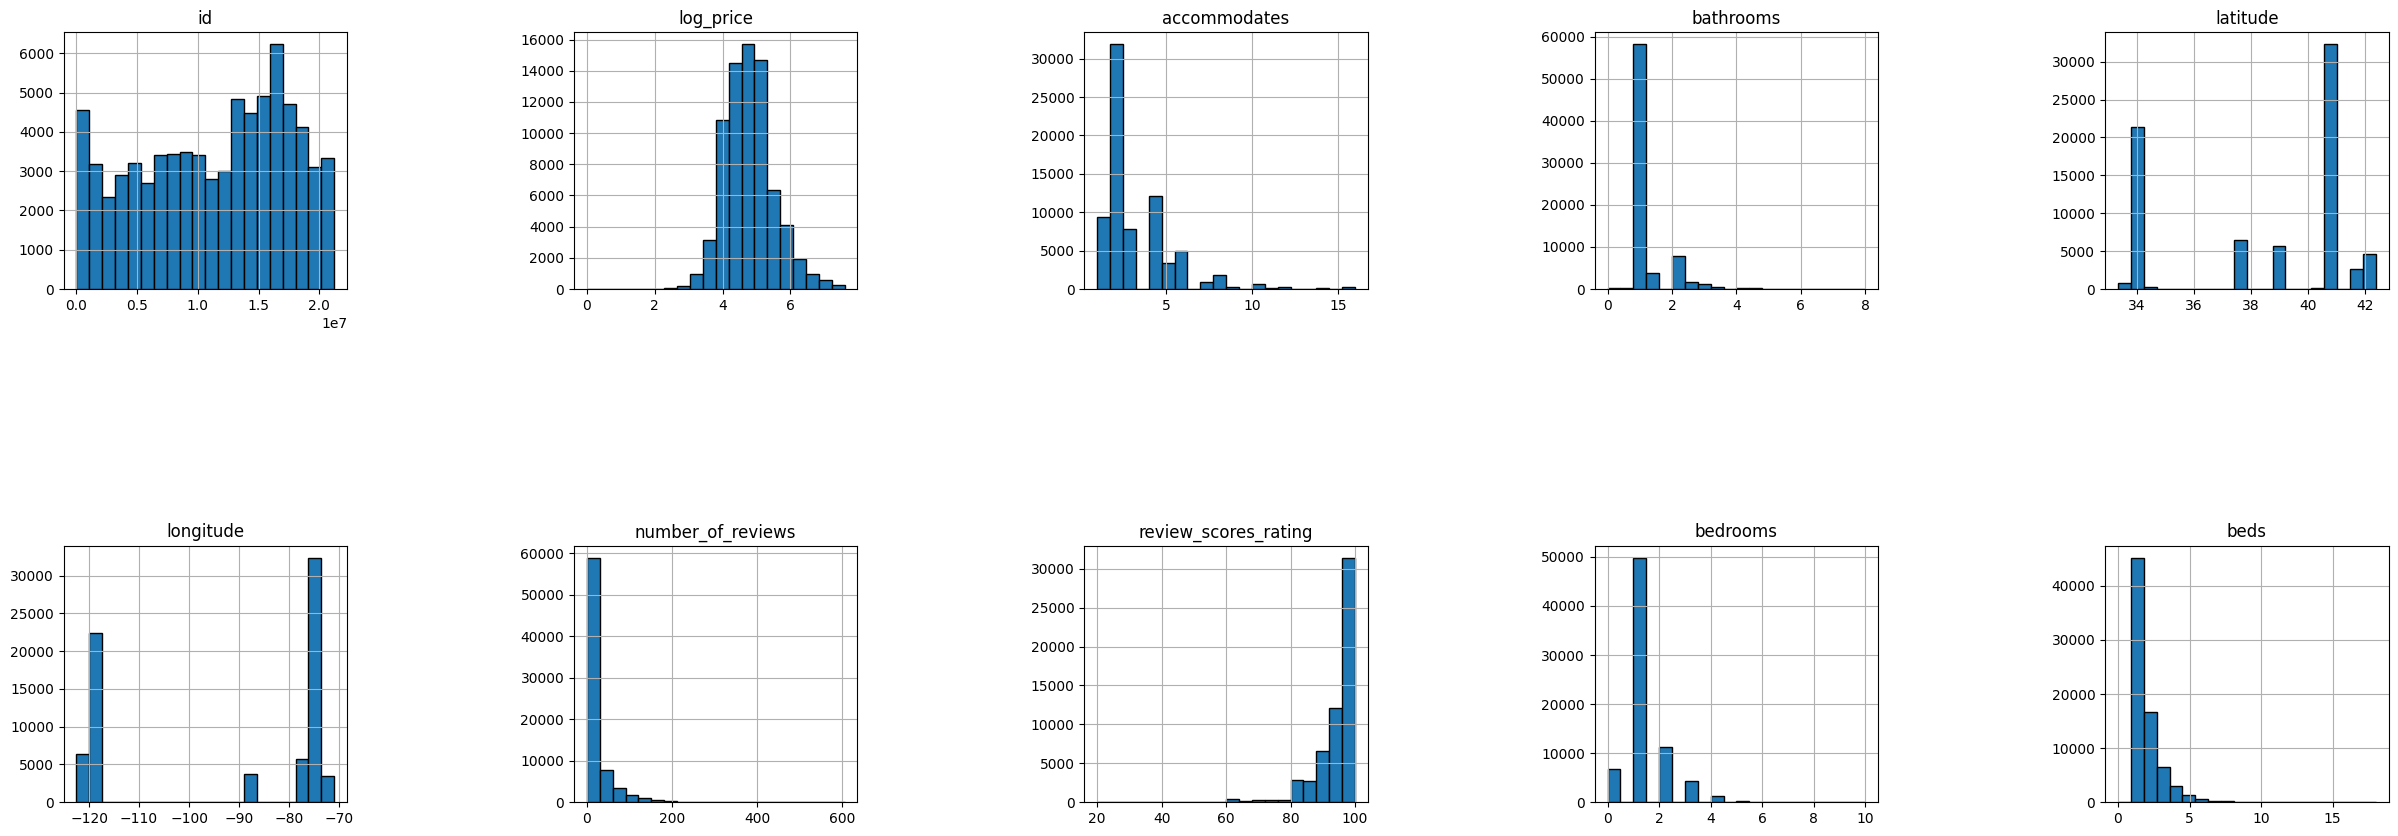

In [8]:
numerical_data = df.select_dtypes(include="number")
numerical_data.hist(
    bins=20, figsize=(30, 30), edgecolor="black", layout=(5, 5)
)
plt.subplots_adjust(hspace=1, wspace=0.8)

У некоторых графиков хорошее распределение, схожее с нормальным, на некоторых графиков малое распределение: кол-во спален, кроватей, ванн и кол-во отзывов

In [9]:
print(df['bedrooms'].describe())

count    74020.000000
mean         1.265793
std          0.852143
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         10.000000
Name: bedrooms, dtype: float64


In [10]:
print(sorted(df['bedrooms'].unique()))

[np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(nan), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0)]


**Сделать как в лекции не получилось, так как в этом датасете в колонках description и amenities слишком много уникальных слов, в id, zipcode, name, thumbnail_url по той же причине**

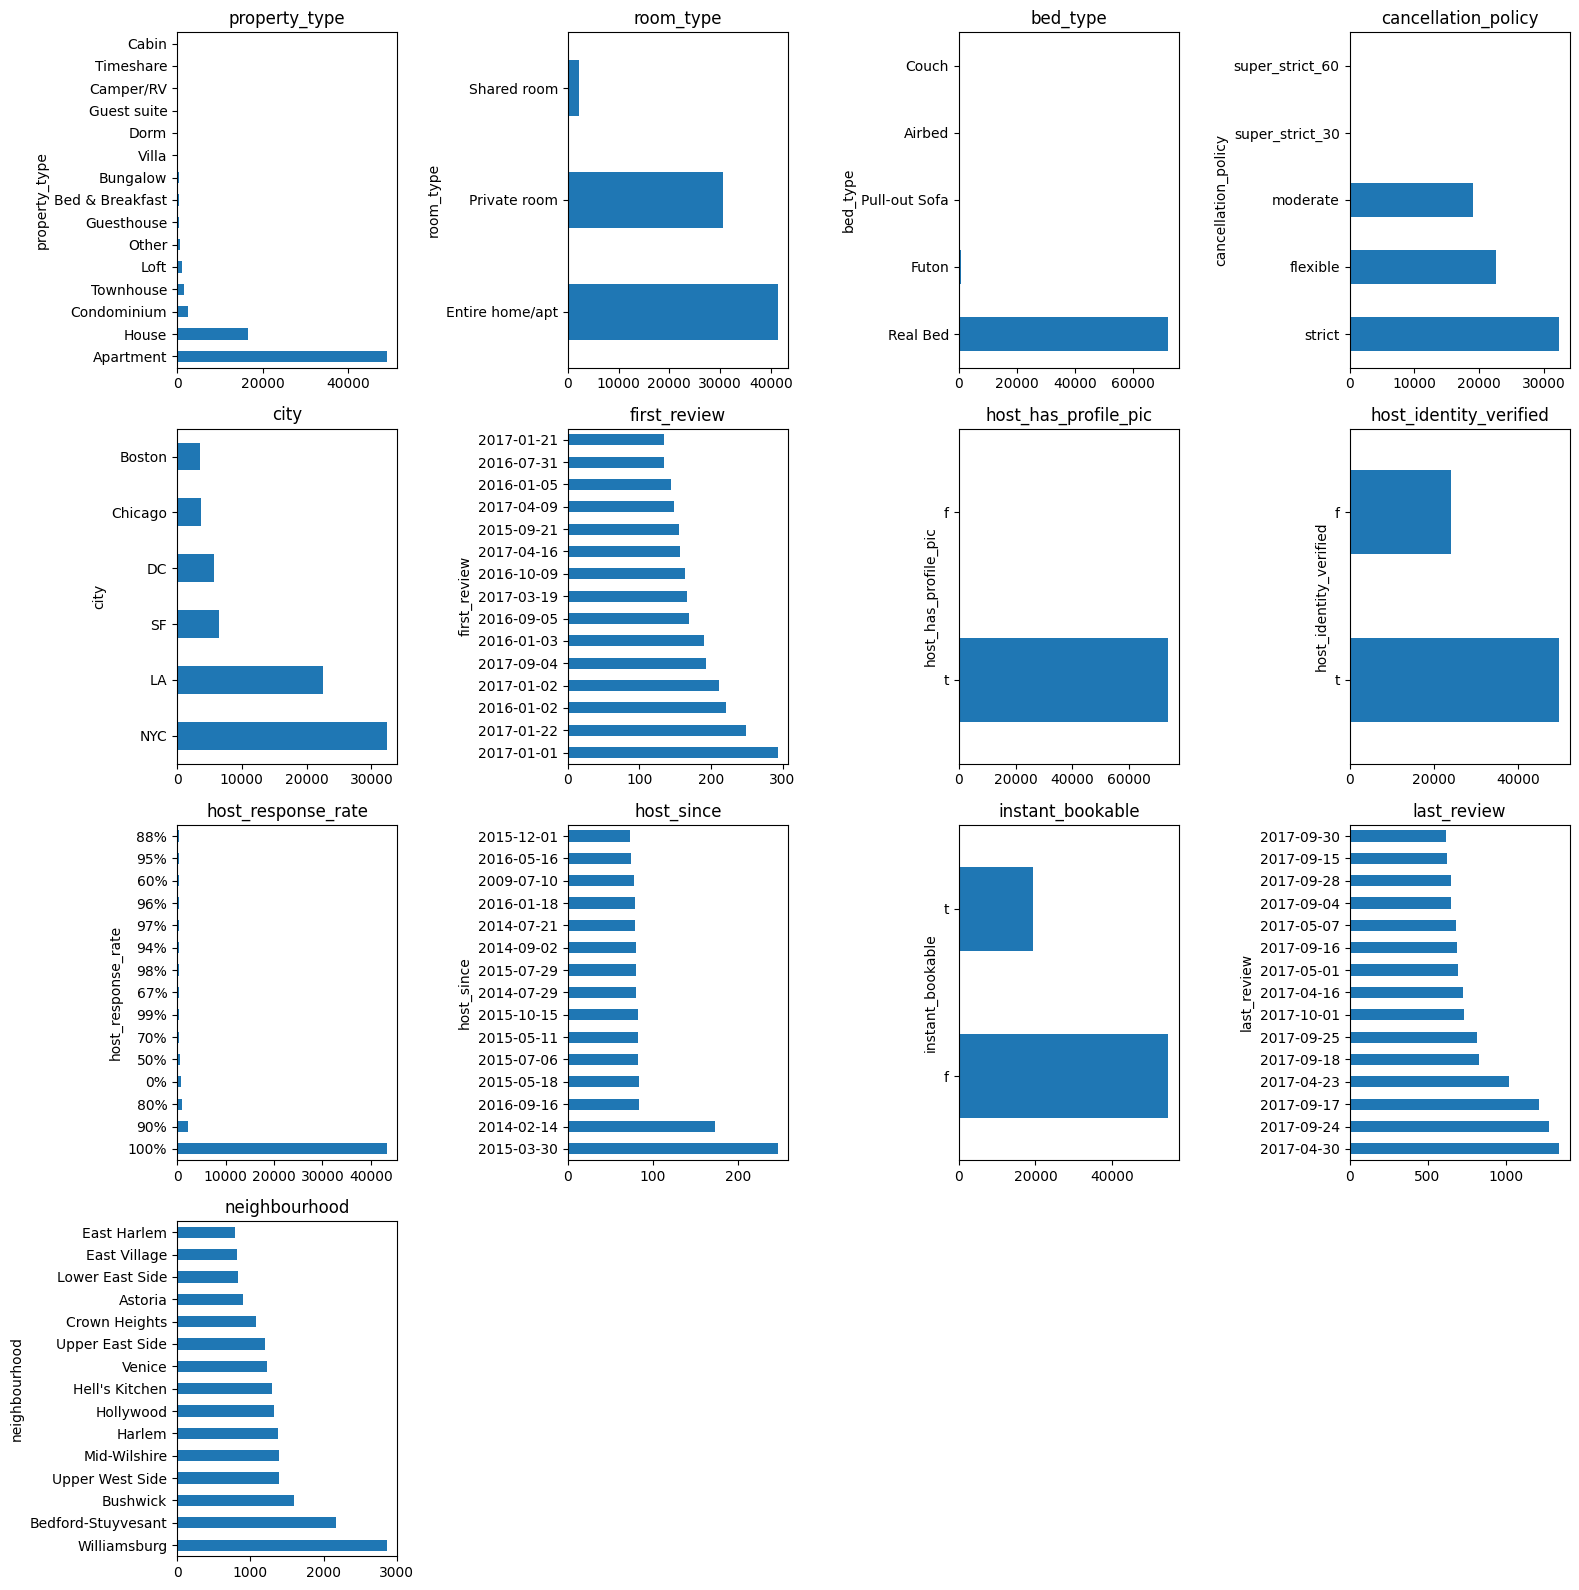

In [11]:
string_data = df.select_dtypes(object)

cols_to_drop = ['description', 'name', 'amenities', 'thumbnail_url', 'id', 'zipcode']
string_data = string_data.drop(columns=[c for c in cols_to_drop if c in string_data.columns])

n_string_features = string_data.shape[1]
nrows, ncols = ceil(n_string_features / 4), 4

fig, axs = plt.subplots(ncols=ncols, nrows=nrows, figsize=(16, nrows * 4))

for feature_name, ax in zip_longest(string_data, axs.ravel()):
    if feature_name is None:
        ax.axis("off")
        continue
    string_data[feature_name].value_counts().head(15).plot.barh(ax=ax)
    ax.set_title(feature_name)

plt.tight_layout()
plt.show()

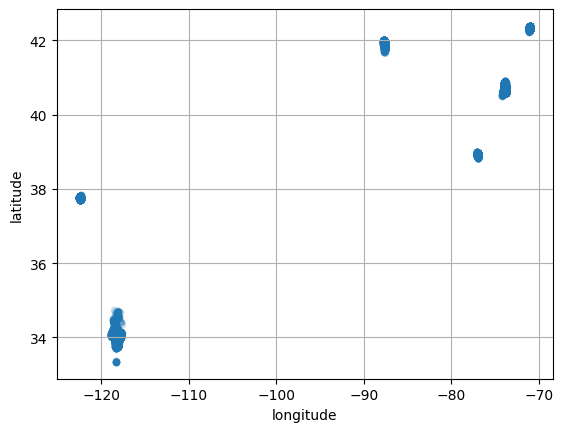

In [12]:
df.plot(kind="scatter", x="longitude", y="latitude", grid=True, alpha=0.2)
plt.show()

У меня в датасете нет колонки популяция, поэтому оставил точки одного размера

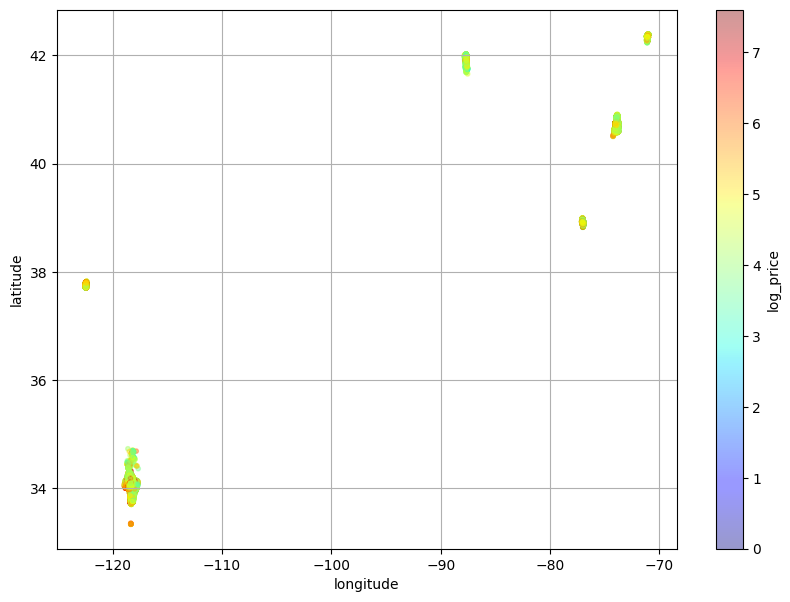

In [13]:
df.plot(
    kind="scatter", x="longitude", y="latitude", grid=True,
    s=10,
    c="log_price", 
    cmap="jet", 
    colorbar=True,
    alpha=0.4,
    figsize=(10, 7),
    sharex=False
)
plt.show()

**Поиск корреляций**

Создаю отдельный тестовый датасет, на котором буду считать корреляции и прочее

In [14]:
train_set = X_train.copy()
train_set["log_price"] = y_train
train_set.head()

,id,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,city,...,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds,log_price
12048,760827,House,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",""A...",4,1.5,Real Bed,flexible,False,LA,...,-118.273390,Comfortable guesthouse in Los Feliz,Los Feliz,12,97.0,https://a0.muscache.com/im/pictures/68126735/8...,90027,2.0,3.0,4.499810
48255,3257345,Apartment,Entire home/apt,"{TV,""Wireless Internet"",Kitchen,""Free parking ...",2,1.0,Real Bed,strict,True,NYC,...,-73.919163,Garden apartment w/ parking! Colorful Cheery S...,Mott Haven,6,87.0,https://a0.muscache.com/im/pictures/de651e45-a...,10454,1.0,1.0,3.806662
39959,13355012,Apartment,Entire home/apt,"{TV,""Air conditioning"",Kitchen,Heating,""Smoke ...",4,1.0,Real Bed,strict,True,NYC,...,-73.953309,Greenpoint Studio w/ KING bed and Sofabed!,Greenpoint,4,80.0,https://a0.muscache.com/im/pictures/02fe96c0-8...,11222,0.0,2.0,5.075174
14926,4565981,Apartment,Private room,{},2,1.0,Real Bed,flexible,True,SF,...,-122.420558,Comfy Valenica Street bedroom,Mission District,0,NaN,https://a0.muscache.com/im/pictures/03292fda-2...,94110,1.0,1.0,4.442651
776,6940108,Apartment,Entire home/apt,"{Internet,""Wireless Internet"",""Air conditionin...",3,1.0,Real Bed,moderate,True,NYC,...,-73.949490,charming brooklyn apartment,Bedford-Stuyvesant,16,99.0,NaN,11216,1.0,1.0,4.744932


In [15]:
corr_matrix = train_set.select_dtypes(include="number").corr()
corr_matrix["log_price"].sort_values(ascending=False)

log_price               1.000000
accommodates            0.569175
bedrooms                0.475462
beds                    0.443746
bathrooms               0.352129
review_scores_rating    0.092239
latitude                0.000427
id                     -0.007145
number_of_reviews      -0.030763
longitude              -0.045283
Name: log_price, dtype: float64

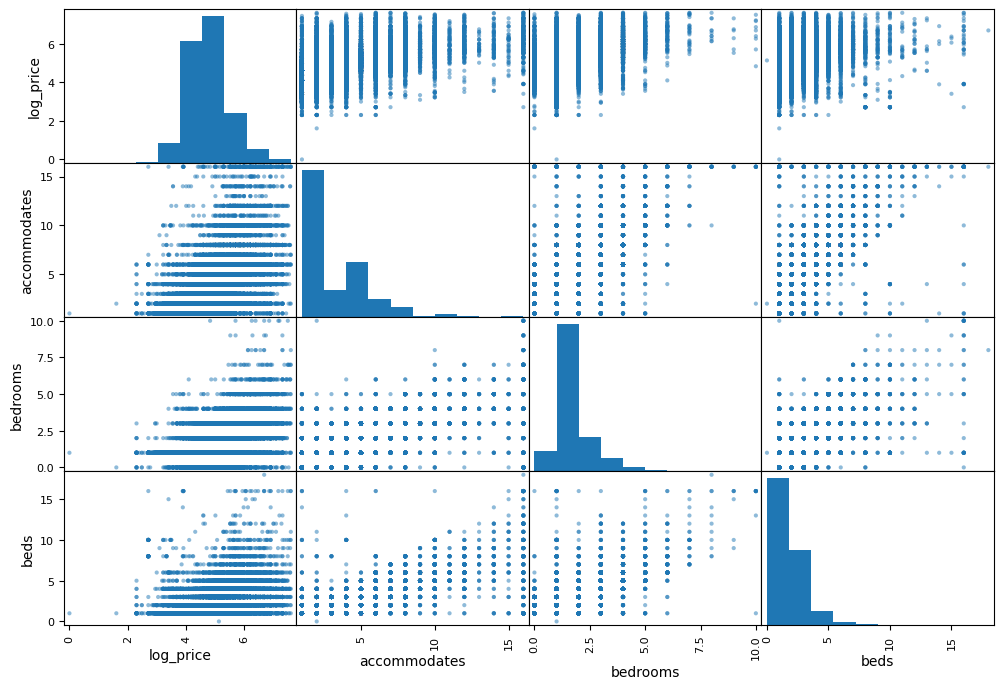

In [16]:
attributes = ["log_price", "accommodates", "bedrooms", "beds"]
pd.plotting.scatter_matrix(train_set[attributes], figsize=(12, 8))
plt.show()

In [17]:
train_set["accommodates"]

12048    4
48255    2
39959    4
14926    2
776      3
        ..
37194    2
6265     1
54886    5
860      2
15795    2
Name: accommodates, Length: 59288, dtype: int64

Наиболее перспективной медианой является accomodates, судя по результатам

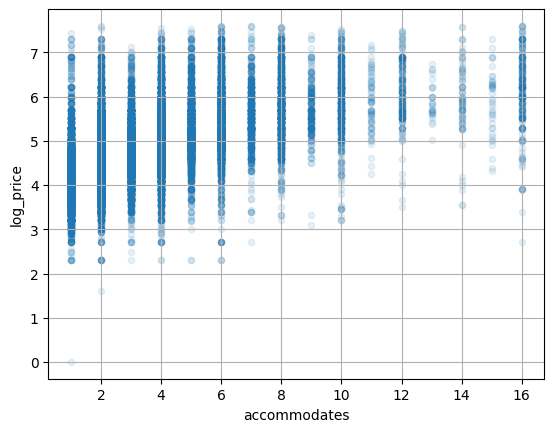

In [18]:
train_set.plot(
    kind="scatter", x="accommodates", y="log_price", alpha=0.1, grid=True)
plt.show() 

Кореляция сильная, но местами присутствуют ошибки в данных, такие как точка в левом нижнем углу

**Эксперименты с комбинациями атрибутов**

In [19]:

train_set["bathrooms_per_bedroom"] = train_set["bathrooms"] / train_set["bedrooms"]

train_set["beds_per_bedroom"] = train_set["beds"] / train_set["bedrooms"]

train_set["accommodates_per_bedroom"] = train_set["accommodates"] / train_set["bedrooms"]

corr_matrix = train_set.select_dtypes(include="number").corr()
print(corr_matrix["log_price"].sort_values(ascending=False))

log_price                   1.000000
accommodates                0.569175
bedrooms                    0.475462
beds                        0.443746
bathrooms                   0.352129
accommodates_per_bedroom    0.239227
review_scores_rating        0.092239
beds_per_bedroom            0.051926
latitude                    0.000427
id                         -0.007145
number_of_reviews          -0.030763
longitude                  -0.045283
bathrooms_per_bedroom      -0.266186
Name: log_price, dtype: float64


bathrooms_per_bedroom выдал отрицательную кореляцию, accommodates_per_bedroom выдал результат ниже, чем accommodates

**Подготовка данных**

Заполнение пустых ячеек

In [20]:
print(df.isnull().sum().sort_values(ascending=False))

host_response_rate        18299
review_scores_rating      16722
first_review              15864
last_review               15827
thumbnail_url              8216
neighbourhood              6872
zipcode                     966
bathrooms                   200
host_identity_verified      188
host_has_profile_pic        188
host_since                  188
beds                        131
bedrooms                     91
description                   0
city                          0
cleaning_fee                  0
cancellation_policy           0
accommodates                  0
bed_type                      0
room_type                     0
amenities                     0
id                            0
log_price                     0
property_type                 0
instant_bookable              0
longitude                     0
latitude                      0
number_of_reviews             0
name                          0
dtype: int64


Просто заполнить среднем арифметическим не получится, попробую использовать все три способа на разных участках

Сначала заполню пропуски в тех ячейках, где большая корреляция

In [21]:
df["bedrooms"] = df["bedrooms"].fillna(df["bedrooms"].median())
df["beds"] = df["beds"].fillna(df["beds"].median())
df["bathrooms"] = df["bathrooms"].fillna(df["bathrooms"].median())

В проценты и рейтинги 16-18 тыщ пропусков, тут тоже больше подойдет медиана, тк отзывы и так высчитываются по среднему. Заполнять даты медианой будет сомнительно. Пока оставлю как есть, если будут ошибки, вернусь к ним. Пропуски в картинках не особо влияют на результат, тк мы не берем их в анализ и у них нет никакой корреляции, значит можно вовсе её удалить. Для neighbourhood, zipcode, host_identity_verified медианы и вовсе не существует, впишу туда unknown

In [22]:
df.drop(columns=["thumbnail_url"], inplace=True)

In [23]:
df["neighbourhood"] = df["neighbourhood"].fillna("Unknown")

In [24]:
df["review_scores_rating"] = df["review_scores_rating"].fillna(df["review_scores_rating"].median())

In [25]:
df['host_response_rate'] = df['host_response_rate'].astype(str).str.replace('%', '')
df['host_response_rate'] = pd.to_numeric(df['host_response_rate'], errors='coerce')
df["host_response_rate"] = df["host_response_rate"].fillna(df["host_response_rate"].median())

In [26]:
print(df.isnull().sum().sort_values(ascending=False))

first_review              15864
last_review               15827
zipcode                     966
host_identity_verified      188
host_has_profile_pic        188
host_since                  188
amenities                     0
accommodates                  0
id                            0
log_price                     0
property_type                 0
room_type                     0
description                   0
city                          0
cleaning_fee                  0
cancellation_policy           0
bed_type                      0
bathrooms                     0
instant_bookable              0
host_response_rate            0
latitude                      0
longitude                     0
neighbourhood                 0
name                          0
number_of_reviews             0
review_scores_rating          0
bedrooms                      0
beds                          0
dtype: int64


Закрою индексы, флпги и прочее не важные данные, где нельзя найти моду и у которых низкая кореляция unknown и самым частым значением

In [27]:
df['zipcode'] = df['zipcode'].fillna("Unknown")
df['host_identity_verified'] = df['host_identity_verified'].fillna(df['host_identity_verified'].mode()[0])
df['host_has_profile_pic'] = df['host_has_profile_pic'].fillna(df['host_has_profile_pic'].mode()[0])
df['host_since'] = df['host_since'].fillna(df['host_since'].mode()[0])

In [28]:
print(df.isnull().sum().sort_values(ascending=False))

first_review              15864
last_review               15827
id                            0
log_price                     0
amenities                     0
accommodates                  0
bathrooms                     0
bed_type                      0
cancellation_policy           0
cleaning_fee                  0
property_type                 0
room_type                     0
description                   0
city                          0
host_identity_verified        0
host_has_profile_pic          0
host_response_rate            0
host_since                    0
instant_bookable              0
latitude                      0
longitude                     0
name                          0
neighbourhood                 0
number_of_reviews             0
review_scores_rating          0
zipcode                       0
bedrooms                      0
beds                          0
dtype: int64


**Текстовые и категориальные признаки**

In [29]:
X = df.drop('log_price', axis=1)
y = df['log_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

train_set = X_train.copy()
train_set["log_price"] = y_train
train_set.head()

,id,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,city,...,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,zipcode,bedrooms,beds,log_price
12048,760827,House,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",""A...",4,1.5,Real Bed,flexible,False,LA,...,34.109039,-118.273390,Comfortable guesthouse in Los Feliz,Los Feliz,12,97.0,90027,2.0,3.0,4.499810
48255,3257345,Apartment,Entire home/apt,"{TV,""Wireless Internet"",Kitchen,""Free parking ...",2,1.0,Real Bed,strict,True,NYC,...,40.812897,-73.919163,Garden apartment w/ parking! Colorful Cheery S...,Mott Haven,6,87.0,10454,1.0,1.0,3.806662
39959,13355012,Apartment,Entire home/apt,"{TV,""Air conditioning"",Kitchen,Heating,""Smoke ...",4,1.0,Real Bed,strict,True,NYC,...,40.737643,-73.953309,Greenpoint Studio w/ KING bed and Sofabed!,Greenpoint,4,80.0,11222,0.0,2.0,5.075174
14926,4565981,Apartment,Private room,{},2,1.0,Real Bed,flexible,True,SF,...,37.759935,-122.420558,Comfy Valenica Street bedroom,Mission District,0,96.0,94110,1.0,1.0,4.442651
776,6940108,Apartment,Entire home/apt,"{Internet,""Wireless Internet"",""Air conditionin...",3,1.0,Real Bed,moderate,True,NYC,...,40.683363,-73.949490,charming brooklyn apartment,Bedford-Stuyvesant,16,99.0,11216,1.0,1.0,4.744932


In [30]:
from sklearn.preprocessing import OneHotEncoder

In [31]:
cat_encoder = OneHotEncoder(handle_unknown='ignore') #Добавил потому, что в тестовых данных попался маяк и вывалились ошибки
housing_cat = train_set[["room_type"]]
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)

In [32]:
print(housing_cat_1hot.toarray()[:5])

[[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]]


Енкодер надо адаптировать под несколько категорий, тк у меня в датасете три категории со словами. Закину сразу три категории и попробую сделать енкодер

In [33]:
cat_attribs = ["room_type", "property_type", "city"]
housing_cat = train_set[cat_attribs]

cat_encoder = OneHotEncoder()
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)

print(cat_encoder.categories_)

[array(['Entire home/apt', 'Private room', 'Shared room'], dtype=object), array(['Apartment', 'Bed & Breakfast', 'Boat', 'Boutique hotel',
       'Bungalow', 'Cabin', 'Camper/RV', 'Casa particular', 'Castle',
       'Cave', 'Chalet', 'Condominium', 'Dorm', 'Earth House',
       'Guest suite', 'Guesthouse', 'Hostel', 'House', 'Hut', 'In-law',
       'Island', 'Loft', 'Other', 'Parking Space', 'Serviced apartment',
       'Tent', 'Timeshare', 'Tipi', 'Townhouse', 'Train', 'Treehouse',
       'Vacation home', 'Villa', 'Yurt'], dtype=object), array(['Boston', 'Chicago', 'DC', 'LA', 'NYC', 'SF'], dtype=object)]


In [34]:
housing_cat_1hot.toarray()

array([[1., 0., 0., ..., 1., 0., 0.],
       [1., 0., 0., ..., 0., 1., 0.],
       [1., 0., 0., ..., 0., 1., 0.],
       ...,
       [1., 0., 0., ..., 1., 0., 0.],
       [0., 1., 0., ..., 0., 1., 0.],
       [0., 1., 0., ..., 1., 0., 0.]])

**Масштабирование признаков**

In [35]:
num_features = ["accommodates", "bedrooms", "bathrooms", "beds", "review_scores_rating"]
housing_num = train_set[num_features]

In [36]:
from sklearn.preprocessing import StandardScaler
std_scaler = StandardScaler()
housing_num_scaled = std_scaler.fit_transform(housing_num)

**Пайплайн и ансамбль модель Random forest**

Повторяю все шаги выше, но теперь в пайплайне

In [37]:
RANDOM_STATE = 42
class AirbnbCleaner(BaseEstimator, TransformerMixin):

    def __init__(self):
        self.medians_ = {}
        self.modes_ = {}

    def fit(self, X, y=None):
        X = X.copy()

        if "host_response_rate" in X.columns:
            s = X["host_response_rate"].astype(str).str.replace("%", "", regex=False)
            s = pd.to_numeric(s, errors="coerce")
            self.medians_["host_response_rate"] = float(np.nanmedian(s))

        for col in ["bedrooms", "beds", "bathrooms", "review_scores_rating"]:
            if col in X.columns:
                self.medians_[col] = float(np.nanmedian(pd.to_numeric(X[col], errors="coerce")))

        for col in ["host_identity_verified", "host_has_profile_pic", "host_since"]:
            if col in X.columns:
                mode = X[col].mode(dropna=True)
                self.modes_[col] = mode.iloc[0] if len(mode) else "Unknown"

        return self

    def transform(self, X):
        X = X.copy()

        if "thumbnail_url" in X.columns:
            X = X.drop(columns=["thumbnail_url"])

        if "neighbourhood" in X.columns:
            X["neighbourhood"] = X["neighbourhood"].fillna("Unknown")
        if "zipcode" in X.columns:
            X["zipcode"] = X["zipcode"].fillna("Unknown")

        if "host_response_rate" in X.columns:
            s = X["host_response_rate"].astype(str).str.replace("%", "", regex=False)
            s = pd.to_numeric(s, errors="coerce")
            med = self.medians_.get("host_response_rate", float(np.nanmedian(s)))
            X["host_response_rate"] = s.fillna(med)

        for col in ["bedrooms", "beds", "bathrooms", "review_scores_rating"]:
            if col in X.columns:
                s = pd.to_numeric(X[col], errors="coerce")
                med = self.medians_.get(col, float(np.nanmedian(s)))
                X[col] = s.fillna(med)

        for col in ["host_identity_verified", "host_has_profile_pic", "host_since"]:
            if col in X.columns:
                X[col] = X[col].fillna(self.modes_.get(col, "Unknown"))

        return X



Удаляю все, что в анализе явно не использовалось как признак

In [ ]:
drop_cols = [
    "log_price",
    "id",
    "amenities",
    "description",
    "name",
    "first_review",
    "last_review",
    "host_since",
]

X_train_raw = X_train.drop(columns=[c for c in drop_cols if c in X_train.columns], errors="ignore")
X_test_raw = X_test.drop(columns=[c for c in drop_cols if c in X_test.columns], errors="ignore")


Набор признаков по корреляции 

In [39]:
numeric_features = [
    "accommodates",
    "bathrooms",
    "bedrooms",
    "beds",
    "review_scores_rating",
    "host_response_rate",
    "latitude",
    "longitude",
    "number_of_reviews",
]

categorical_features = [
    "room_type",
    "property_type",
    "city",
    "bed_type",
    "cancellation_policy",
    "cleaning_fee",
    "instant_bookable",
    "host_has_profile_pic",
    "host_identity_verified",
    "neighbourhood",
    "zipcode",
]

numeric_features = [c for c in numeric_features if c in X_train_raw.columns]
categorical_features = [c for c in categorical_features if c in X_train_raw.columns]

preprocess = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                ]
            ),
            numeric_features,
        ),
        (
            "cat",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("ohe", OneHotEncoder(handle_unknown="ignore", min_frequency=50)),
                ]
            ),
            categorical_features,
        ),
    ],
    remainder="drop",
)

pipe = Pipeline(
    steps=[
        ("clean", AirbnbCleaner()),
        ("prep", preprocess),
        ("model", ExtraTreesRegressor(random_state=RANDOM_STATE, n_jobs=-1)),
    ]
)

Подбор гиперпараметров (у меня слабый процессор, а на видеокарту рассчеты через Scikitlearn перекинуть не получилось, поэтому на подвыборке train) + кросс-валидация

In [ ]:
rng = np.random.default_rng(RANDOM_STATE)
train_idx = np.arange(len(X_train_raw))
sub_n = min(20000, len(train_idx))
sub_idx = rng.choice(train_idx, size=sub_n, replace=False)
X_tune = X_train_raw.iloc[sub_idx]
y_tune = np.asarray(y_train)[sub_idx]

cv_tune = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

param_distributions = {
    "model__n_estimators": [300, 600],
    "model__max_depth": [None, 20, 40],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", 0.5, 0.8],
}

search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_distributions,
    n_iter=12,
    scoring="neg_root_mean_squared_error",
    cv=cv_tune,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)

search.fit(X_tune, y_tune)

print(search.best_params_)
print(f"RMSE CV (mean, tune): {-search.best_score_:.4f}")

best_model = search.best_estimator_

# CV на полном train (3-fold, чтобы не уходило в 20+ минут)
cv_final = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
cv_scores = -cross_val_score(
    best_model,
    X_train_raw,
    y_train,
    cv=cv_final,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)
print("\n Кросс-валидация на полном train ")
print(f"RMSE CV: mean={cv_scores.mean():.4f}, std={cv_scores.std():.4f}")

# Финальная оценка на тесте + 95% ДИ
best_model.fit(X_train_raw, y_train)
y_pred = best_model.predict(X_test_raw)
rmse_test = root_mean_squared_error(y_test, y_pred)
print("\nТест ")
print(f"RMSE on test: {rmse_test:.4f}")

B = 500
idx = np.arange(len(y_test))
rmse_boot = np.empty(B, dtype=float)

y_test_arr = np.asarray(y_test)
y_pred_arr = np.asarray(y_pred)

for b in range(B):
    s = rng.choice(idx, size=len(idx), replace=True)
    rmse_boot[b] = root_mean_squared_error(y_test_arr[s], y_pred_arr[s])

ci_low, ci_high = np.quantile(rmse_boot, [0.025, 0.975])
print("\n 95% доверительный интервал")
print(f"95% для RMSE (bootstrap, B={B}): [{ci_low:.4f}, {ci_high:.4f}]")


Fitting 3 folds for each of 12 candidates, totalling 36 fits
{'model__n_estimators': 600, 'model__min_samples_split': 10, 'model__min_samples_leaf': 2, 'model__max_features': 0.5, 'model__max_depth': None}
RMSE CV (mean, tune): 0.4300

--- Кросс-валидация на полном train 
RMSE CV: mean=0.4124, std=0.0019

--- Тест ---
RMSE on test: 0.4026

--- 95% доверительный интервал ---
95% CI for RMSE (bootstrap, B=500): [0.3939, 0.4111]


Fitting 3 folds for each of 12 candidates, totalling 36 fits
{'model__n_estimators': 600, 'model__min_samples_split': 10, 'model__min_samples_leaf': 2, 'model__max_features': 0.5, 'model__max_depth': None}
RMSE CV (mean, tune): 0.4300

Кросс-валидация на полном train 
RMSE CV: mean=0.4124, std=0.0019

 Тест 
RMSE on test: 0.4026

95% доверительный интервал
95% CI для RMSE (bootstrap, B=500): [0.3939, 0.4111]